# Generate water price and availability timeseries

- Water availability should be given as a variation, so each data point represents the variation with respect to the previous one.
- We should start with an initial value, and then based on the precipitation add, and substract some amount due to evaporation.
- The evaporation rate probably should be a linear function of the weather conditions (HR, Tamb): $\dot{V}_{loss} = a \cdot HR + b \cdot T_{amb} + c, \in [\underline{\dot{V}_{loss}}, \overline{\dot{V}_{loss}}]$
- To simplify the problem, assume a constat loss rate
- The relationship precipitation and water availability is arbitrary. To start with something, model it so that during winter the wet cooling tower could operate exclusively by using this water source, while on summer it would not suffice.


[Data source](https://collab.psa.es/apps/files/files/1267204?dir=/E47/E47_TECHNICAL/DESAL%20PROJECTS/1K235_SOLHYCOOL/Ejecuci%C3%B3n/T2.2%20-%20Optimizaci%C3%B3n%20de%20la%20operaci%C3%B3n&openfile=true)

In [1]:
from pathlib import Path
from loguru import logger
import datetime
import numpy as np
import pandas as pd
from datetime import time

from solhycool_evaluation.utils import repeat_and_align_index

%load_ext autoreload
%autoreload 2

# Constants
data_path: Path = Path("../../data/datasets/partial")
output_path: Path = Path("../results/visualizations")
data_output_path: Path = data_path
electricity_price_data_path: Path = data_path / "electricity_price_data_20211231_20241231.h5"
weather_data_path: Path = data_path / "tmy_2005_Borg_El_Arab.h5" # tabernas guadix Borg_El_Arab

# Parameters
environment_id: str = "_med_" # "_med_" # "_psa_" # _andasol_
water_price_egypt = 0.06047057835 # €/m³
water_price_morocco = 0.0290538951 # €/m³
year_start: int = 2022
year_end: int = 2024

# Alternative A. Model water availability as a function of precipitation data
use_alternative_cost: bool = True
Vavail_max: float = 1.2 # m³/day
Vavail_min: float = 0.0 # m³/day
availability_start_time = time(8, 0)  # e.g., water becomes available from 08:00 onward

# Alternative B. Asign some initial value and some rando variation factor
Vavail0: float = 20. # Period initial volume, m³
evap_rate: float = -0.0 # Evaporation rate, m³/h

# Alternative source incurs in a cost similar to electricity
alternative_source_cost = pd.read_hdf(electricity_price_data_path)["Ce_spot_market_price_eur_kWh"] * 2 * 10 # /100 (l/h)*1000l/m³
alternative_source_cost_multiplier = 40.0 # Relative cost increase factor of source 2 with respect to source 1, -


## Prices

In [2]:
# Create a pandas series with one-hour resolution
start_date = datetime.datetime(year_start, 1, 1, 0, 0, 0)
end_date = datetime.datetime(year_end, 12, 31, 23, 0, 0)
date_rng = pd.date_range(start=start_date, end=end_date, freq='h', tz='UTC')
fname: str = f"water_data{environment_id}{start_date:%Y%m%d}_{end_date:%Y%m%d}"

# Initialize dataframe
df = pd.DataFrame(
    data={
        "water_price_morocco_eur_m3": water_price_morocco,
        "water_price_morocco_alternative_eur_m3": alternative_source_cost if use_alternative_cost else water_price_morocco * alternative_source_cost_multiplier,
        "water_price_egypt_eur_m3": water_price_egypt,
        "water_price_egypt_alternative_eur_m3": alternative_source_cost if use_alternative_cost else water_price_egypt * alternative_source_cost_multiplier,
    },
    index=date_rng,
)
# Add columns for the water price in liters
for col in df.columns:
    df[col.replace("_eur_m3", "_eur_l")] = df[col] / 1000.0

df


,water_price_morocco_eur_m3,water_price_morocco_alternative_eur_m3,water_price_egypt_eur_m3,water_price_egypt_alternative_eur_m3,water_price_morocco_eur_l,water_price_morocco_alternative_eur_l,water_price_egypt_eur_l,water_price_egypt_alternative_eur_l
2022-01-01 00:00:00+00:00,0.029054,2.2980,0.060471,2.2980,0.000029,0.002298,0.00006,0.002298
2022-01-01 01:00:00+00:00,0.029054,2.2774,0.060471,2.2774,0.000029,0.002277,0.00006,0.002277
2022-01-01 02:00:00+00:00,0.029054,1.9560,0.060471,1.9560,0.000029,0.001956,0.00006,0.001956
2022-01-01 03:00:00+00:00,0.029054,1.9560,0.060471,1.9560,0.000029,0.001956,0.00006,0.001956
2022-01-01 04:00:00+00:00,0.029054,1.9148,0.060471,1.9148,0.000029,0.001915,0.00006,0.001915
...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00+00:00,0.029054,3.1220,0.060471,3.1220,0.000029,0.003122,0.00006,0.003122
2024-12-31 20:00:00+00:00,0.029054,3.0170,0.060471,3.0170,0.000029,0.003017,0.00006,0.003017
2024-12-31 21:00:00+00:00,0.029054,2.8880,0.060471,2.8880,0.000029,0.002888,0.00006,0.002888
2024-12-31 22:00:00+00:00,0.029054,2.7874,0.060471,2.7874,0.000029,0.002787,0.00006,0.002787


## Model water availability as a function of precipitation data

<Axes: xlabel='time'>

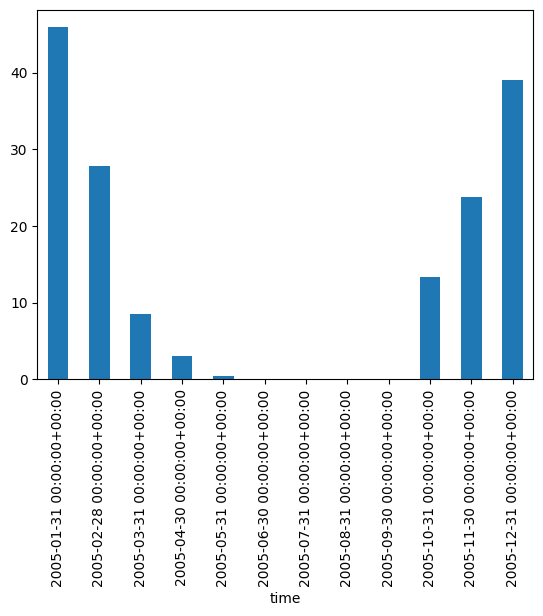

In [3]:
# Read weather data and resample precipitation data to monthly acumulating the precipitation per month
precip_data = pd.read_hdf(weather_data_path)["precip_mm"].resample("ME").sum()
display(precip_data.plot(kind="bar"))


In [5]:
conversion_factor = Vavail_max / precip_data.max()  # m³/mm

# Convert daily precipitation to daily volume
Vavail_daily = (precip_data * conversion_factor).rename("Vavail_m3")

# Resample to hourly with repeat (forward-fill)
Vavail_hourly = repeat_and_align_index(
    Vavail_daily.resample("h").ffill(), new_index=df.index, year_range=(year_start, year_end)
)

# Build a proper Series mask aligned with Vavail_hourly index
mask_available = pd.Series(Vavail_hourly.index.time >= availability_start_time, index=Vavail_hourly.index)

# Apply mask
Vavail_hourly_masked = Vavail_hourly.where(mask_available, 0)

# Assign to DataFrame
df["Vavail_m3"] = Vavail_hourly_masked
df["Vavail_l"] = df["Vavail_m3"] * 1e3


In [11]:
# # For now just assign some initial value at the start of the timeseries,
# # and then increase/decrease it by the same amount every day

# # deltaV: hourly volume variation (m³/h)
# # Vavail: available water volume (m³)

# # Terribly inefficient, but whatever it's only done once
# current_month = start_date.month
# for single_date in pd.date_range(start=start_date, end=end_date, freq='h', tz='UTC'):
#     if single_date.month != current_month:
#         current_month = single_date.month
#         Vavail = Vavail0 # Reset available volume every month
#     deltaV = evap_rate + np.random.uniform(0.8*evap_rate, 1.2*evap_rate)
#     Vavail = Vavail0 + deltaV
#     df.loc[single_date, "Vavail_m3"] = Vavail
#     df.loc[single_date, "deltaV_m3_h"] = deltaV
#     df.loc[single_date, "Vavail_l"] = Vavail*1e3
#     df.loc[single_date, "deltaV_l_h"] = deltaV*1e3

# df


In [6]:
# Export dataframe including additional units (liters)
df.to_hdf(data_output_path / f"{fname}.h5", key="data", mode="w", format="table")
df.to_csv(data_output_path / f"{fname}.csv")

logger.info(f"Exported data to {data_output_path / fname}")


2025-04-13 10:05:34.373 | INFO     | __main__:<module>:5 - Exported data to ../../data/datasets/partial/water_data_med_20220101_20241231


In [7]:
df = pd.read_hdf(data_output_path / f"{fname}.h5", index_col=0, parse_dates=True)
df


,water_price_morocco_eur_m3,water_price_morocco_alternative_eur_m3,water_price_egypt_eur_m3,water_price_egypt_alternative_eur_m3,water_price_morocco_eur_l,water_price_morocco_alternative_eur_l,water_price_egypt_eur_l,water_price_egypt_alternative_eur_l,Vavail_m3,Vavail_l
2022-01-01 00:00:00+00:00,0.029054,2.2980,0.060471,2.2980,0.000029,0.002298,0.00006,0.002298,0.000000,0.000000
2022-01-01 01:00:00+00:00,0.029054,2.2774,0.060471,2.2774,0.000029,0.002277,0.00006,0.002277,0.000000,0.000000
2022-01-01 02:00:00+00:00,0.029054,1.9560,0.060471,1.9560,0.000029,0.001956,0.00006,0.001956,0.000000,0.000000
2022-01-01 03:00:00+00:00,0.029054,1.9560,0.060471,1.9560,0.000029,0.001956,0.00006,0.001956,0.000000,0.000000
2022-01-01 04:00:00+00:00,0.029054,1.9148,0.060471,1.9148,0.000029,0.001915,0.00006,0.001915,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00+00:00,0.029054,3.1220,0.060471,3.1220,0.000029,0.003122,0.00006,0.003122,1.019608,1019.607843
2024-12-31 20:00:00+00:00,0.029054,3.0170,0.060471,3.0170,0.000029,0.003017,0.00006,0.003017,1.019608,1019.607843
2024-12-31 21:00:00+00:00,0.029054,2.8880,0.060471,2.8880,0.000029,0.002888,0.00006,0.002888,1.019608,1019.607843
2024-12-31 22:00:00+00:00,0.029054,2.7874,0.060471,2.7874,0.000029,0.002787,0.00006,0.002787,1.019608,1019.607843


In [8]:
# Visualize data

from plotly_resampler import FigureWidgetResampler
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np

var_ids: list[str] = [
    ["water_price_morocco_eur_m3", "water_price_egypt_eur_m3", "water_price_morocco_alternative_eur_m3", "water_price_egypt_alternative_eur_m3"], 
    "Vavail_m3",
]
var_units: list[str] = ["€/m<sup>3</sup>","m<sup>3</sup>"]

fig = make_subplots(rows=len(var_ids), cols=1, shared_xaxes=True)
fig = FigureWidgetResampler(fig)

for i, (var_id, var_unit) in enumerate(zip(var_ids, var_units)):
    var_id = [var_id] if not isinstance(var_id, list) else var_id
    
    for v_id in var_id:
        fig.add_trace(
            go.Scattergl(name=v_id, showlegend=True), 
            hf_x=df.index, 
            hf_y=np.ascontiguousarray( df[v_id] ), 
            # max_n_samples=2_000,
            row=i + 1, col=1
        )
    fig.update_yaxes(title_text=var_unit, row=i + 1)
    
# Temporal
data_L = pd.read_csv(data_path / "water_data_andasol_escalada_20050101_20051231.csv", index_col=0, parse_dates=True)
data_L = repeat_and_align_index(data_L, new_index=df.index, year_range=(year_start, year_end))
fig.add_trace(
    go.Scattergl(name="data L", showlegend=True), 
    hf_x=data_L.index, 
    hf_y=np.ascontiguousarray( data_L[v_id] ), 
    # max_n_samples=2_000,
    row=2, col=1
)

fig.update_layout(
    height=1000,
    width=800,
    title="<b>Environment variables</b>",
    title_x=0.1,
    legend_traceorder="normal",
    legend=dict(orientation="h", y=1.15, xanchor="left", x=0),
    margin=dict(l=20, r=20, t=250, b=20),
)

fig


FigureWidgetResampler({
    'data': [{'name': ('<b style="color:sandybrown">[R' ... ' style="color:#fc9944">~1D</i>'),
              'showlegend': True,
              'type': 'scattergl',
              'uid': '7415e387-8d13-4054-b402-f6a7c1763811',
              'x': array([datetime.datetime(2022, 1, 1, 0, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2022, 1, 1, 1, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2022, 1, 2, 4, 0, tzinfo=datetime.timezone.utc), ...,
                          datetime.datetime(2024, 12, 29, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2024, 12, 30, 7, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2024, 12, 31, 23, 0, tzinfo=datetime.timezone.utc)],
                         shape=(1000,), dtype=object),
              'xaxis': 'x',
              'y': array([0.0290539, 0.0290539, 0.0290539, ..., 0.0290539, 0.0290539, 0.0290539],

In [15]:
from phd_visualizations import save_figure

start, end = fig.layout.xaxis.range
save_figure(fig, f"solhycool_water_viz{environment_id}{start[:10].replace('-', '')}_{end[:10].replace('-', '')}", 
            figure_path=output_path, formats=["png", "svg"])


TypeError: cannot unpack non-iterable NoneType object